# Comparación de modelos de machine learning para la predicción de cáncer de pulmón

## Importación de librerías y modelos

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils import resample
import optuna
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("Librerías importadas correctamente")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente


## Proceso ETL y visualizaciones

### Carga de Dataset

In [2]:
DATA_PATH = "data/dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print(f"Datos: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Datos: 460292 filas y 25 columnas


,Country,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Rural_or_Urban,Socioeconomic_Status,Healthcare_Access,...,Treatment_Access,Clinical_Trial_Access,Language_Barrier,Mortality_Risk,5_Year_Survival_Probability,Delay_in_Diagnosis,Family_History,Indoor_Smoke_Exposure,Tobacco_Marketing_Exposure,Final_Prediction
0,Russia,82,Male,Former Smoker,Yes,Medium,No,Urban,High,Limited,...,Partial,Yes,No,0.263278,0.797576,Yes,No,No,No,No
1,Thailand,66,Female,Former Smoker,No,High,No,Rural,Middle,Good,...,Partial,Yes,No,0.154697,0.336674,Yes,No,No,Yes,No
2,Colombia,87,Male,Former Smoker,No,Medium,No,Urban,Low,Poor,...,Partial,Yes,No,0.607435,0.063621,No,No,No,Yes,No
3,Egypt,51,Female,Former Smoker,No,Low,Yes,Rural,High,Good,...,Full,No,No,0.081184,0.336814,No,No,No,Yes,No
4,DR Congo,43,Male,Former Smoker,No,High,No,Urban,Middle,Good,...,Full,No,No,0.643276,0.820103,No,No,No,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460292 entries, 0 to 460291
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      460292 non-null  object 
 1   Age                          460292 non-null  int64  
 2   Gender                       460292 non-null  object 
 3   Smoking_Status               460292 non-null  object 
 4   Second_Hand_Smoke            460292 non-null  object 
 5   Air_Pollution_Exposure       460292 non-null  object 
 6   Occupation_Exposure          460292 non-null  object 
 7   Rural_or_Urban               460292 non-null  object 
 8   Socioeconomic_Status         460292 non-null  object 
 9   Healthcare_Access            460292 non-null  object 
 10  Insurance_Coverage           460292 non-null  object 
 11  Screening_Availability       460292 non-null  object 
 12  Stage_at_Diagnosis           460292 non-null  object 
 13 

### Variable objetivo

In [4]:
target = 'Final_Prediction'
df[target] = df[target].map({'Yes':1, 'No':0})

### Eliminación de valores nulos

In [5]:
# Rellenar nulos con la moda
if 'Treatment_Access' in df.columns:
    mode_val = df['Treatment_Access'].mode()[0]
    df['Treatment_Access'] = df['Treatment_Access'].fillna(mode_val)

# Rellenar nulos con Unkmown
if 'Mutation_Type' in df.columns:
    df['Mutation_Type'] = df['Mutation_Type'].fillna('Unknown')

### Mapeo para variables ordinales

In [6]:
ordinal_mappings = {
    'Smoking_Status': {'Non-Smoker': 0, 'Former Smoker': 1, 'Smoker': 2},
    'Air_Pollution_Exposure': {'Low': 0, 'Medium': 1, 'High': 2},
    'Socioeconomic_Status': {'Low': 0, 'Middle': 1, 'High': 2},
    'Healthcare_Access': {'Poor': 0, 'Limited': 1, 'Good': 2},
    'Stage_at_Diagnosis': {'I': 1, 'II': 2, 'III': 3, 'IV': 4},
    'Treatment_Access': {'None': 0, 'Partial': 1, 'Full': 2}
}

# Aplicar mapeo
for col, mapping in ordinal_mappings.items():
  if col in df.columns:
    df[col] = df[col].map(mapping)

### Mapeo para variables binarias

In [7]:
binary_cols = ['Second_Hand_Smoke', 'Occupation_Exposure', 'Insurance_Coverage',
               'Screening_Availability', 'Clinical_Trial_Access', 'Language_Barrier',
               'Delay_in_Diagnosis', 'Family_History', 'Indoor_Smoke_Exposure',
               'Tobacco_Marketing_Exposure', 'Gender']

# Mapeo
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
  if col in df.columns:
    df[col] = df[col].map(binary_map)

### Columnas numéricas continuas (escalar) y nominales restantes (one-hot)

In [8]:
# Columnas numéricas continuas
numeric_cols = ['Age', 'Mortality_Risk', '5_Year_Survival_Probability']
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Columnas nominales restantes
already_handled = set(ordinal_mappings.keys()) | set(binary_cols) | set(numeric_cols) | {target} # Escluir las anteriores
categorical_nominal = [col for col in df.columns if col not in already_handled]

# One-hot
df = pd.get_dummies(df, columns=categorical_nominal, drop_first=True)

df.head()

,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Socioeconomic_Status,Healthcare_Access,Insurance_Coverage,Screening_Availability,...,Country_Thailand,Country_Turkey,Country_UK,Country_USA,Country_Vietnam,Rural_or_Urban_Urban,Cancer_Type_SCLC,Mutation_Type_EGFR,Mutation_Type_KRAS,Mutation_Type_Unknown
0,82,1,1,1,1,0,2,1,1,1,...,False,False,False,False,False,True,False,True,False,False
1,66,0,1,0,2,0,1,2,0,0,...,True,False,False,False,False,False,False,True,False,False
2,87,1,1,0,1,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
3,51,0,1,0,0,1,2,2,0,0,...,False,False,False,False,False,False,False,True,False,False
4,43,1,1,0,2,0,1,2,1,0,...,False,False,False,False,False,True,False,False,False,True


### Convertir variables booleanas a enteros

In [9]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

### Verificación final

In [10]:
print(f"Total de nulos en el dataset: {df.isnull().sum().sum()}")

Total de nulos en el dataset: 0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460292 entries, 0 to 460291
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          460292 non-null  int64  
 1   Gender                       460292 non-null  int64  
 2   Smoking_Status               460292 non-null  int64  
 3   Second_Hand_Smoke            460292 non-null  int64  
 4   Air_Pollution_Exposure       460292 non-null  int64  
 5   Occupation_Exposure          460292 non-null  int64  
 6   Socioeconomic_Status         460292 non-null  int64  
 7   Healthcare_Access            460292 non-null  int64  
 8   Insurance_Coverage           460292 non-null  int64  
 9   Screening_Availability       460292 non-null  int64  
 10  Stage_at_Diagnosis           460292 non-null  int64  
 11  Treatment_Access             460292 non-null  int64  
 12  Clinical_Trial_Access        460292 non-null  int64  
 13 

In [12]:
df.describe()

,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Socioeconomic_Status,Healthcare_Access,Insurance_Coverage,Screening_Availability,...,Country_Thailand,Country_Turkey,Country_UK,Country_USA,Country_Vietnam,Rural_or_Urban_Urban,Cancer_Type_SCLC,Mutation_Type_EGFR,Mutation_Type_KRAS,Mutation_Type_Unknown
count,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,...,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000
mean,60.044183,0.500574,1.000463,0.300257,0.798109,0.250065,0.900400,1.299703,0.701409,0.600306,...,0.033674,0.033444,0.033305,0.033342,0.033335,0.699964,0.150585,0.299903,0.200108,0.300186
std,17.590029,0.500000,0.817074,0.458370,0.747899,0.433051,0.699941,0.781555,0.457640,0.489836,...,0.180390,0.179793,0.179432,0.179528,0.179511,0.458274,0.357644,0.458216,0.400081,0.458339
min,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,60.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,75.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,90.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Correlación con variable objetivo
No existe una correlación fuerte en ninguna variable

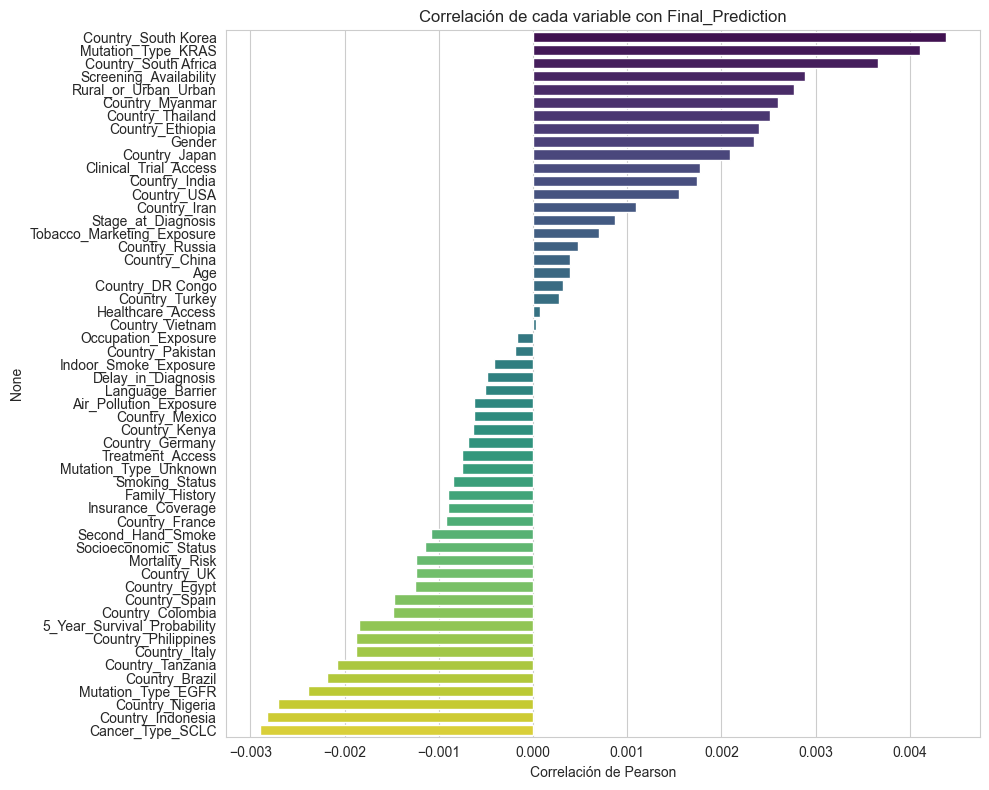

In [13]:
# Calcular correlación con el objetivo y ordenar
corr_target = df.corr()['Final_Prediction'].drop('Final_Prediction').sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title('Correlación de cada variable con Final_Prediction')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

### Heatmap con 15 variables más correlacionadas

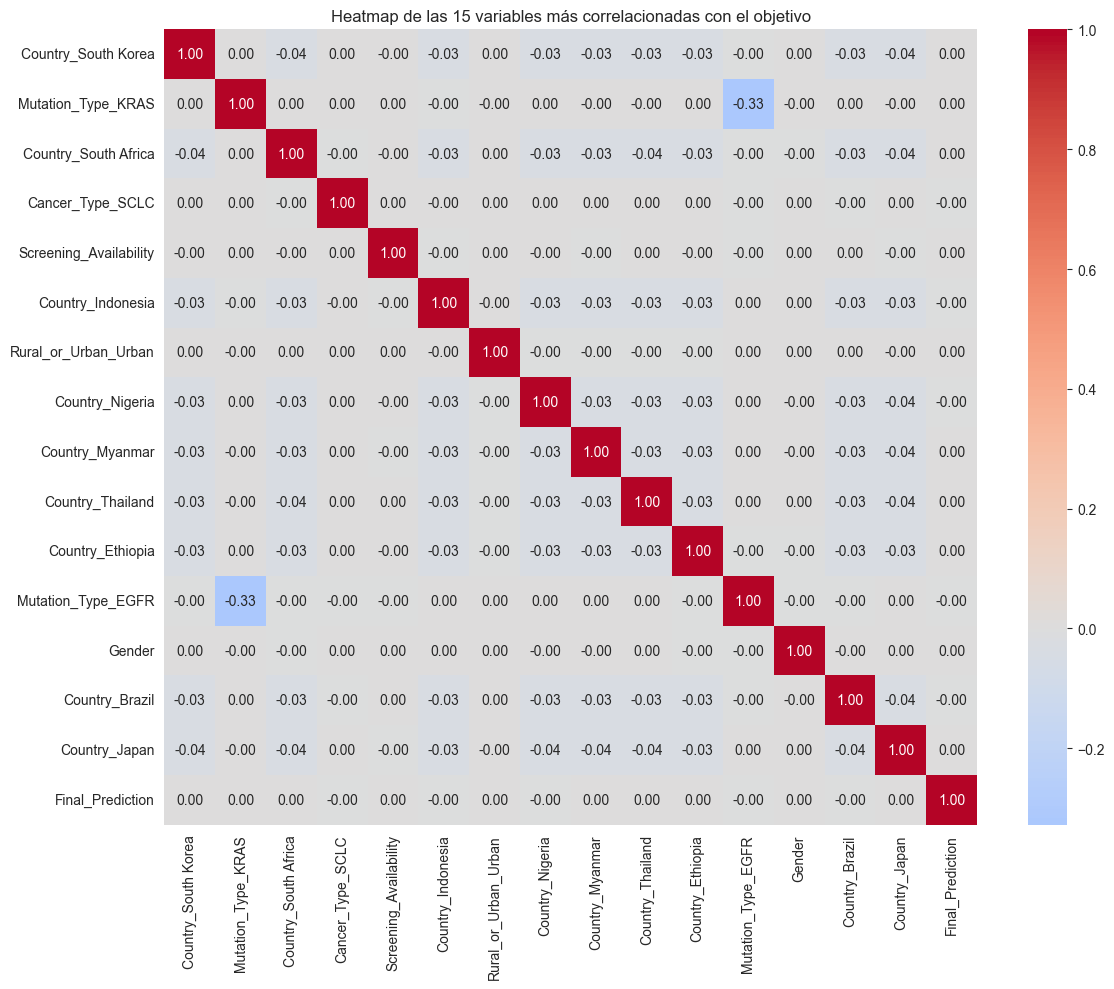

In [14]:
top_vars = corr_target.abs().nlargest(15).index.tolist() + ['Final_Prediction']
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_vars].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap de las 15 variables más correlacionadas con el objetivo')
plt.tight_layout()
plt.show()

## Ingeniería de características avanzada

In [15]:
# Copia de trabajo
df_feat = df.copy()
target_col = 'Final_Prediction'

### Agrupar países a continentes

In [16]:
country_cols = [c for c in df_feat.columns if c.startswith('Country_')]

if country_cols:
  mapeo_continente = {
    'USA':'América', 'Canada':'América', 'Mexico':'América', 'Brazil':'América',
    'Colombia':'América', 'Argentina':'América', 'Peru':'América', 'Chile':'América',
    'UK':'Europa', 'Germany':'Europa', 'France':'Europa', 'Spain':'Europa',
    'Italy':'Europa', 'Russia':'Europa/Asia', 'Turkey':'Asia',
    'China':'Asia', 'Japan':'Asia', 'India':'Asia', 'South Korea':'Asia',
    'Indonesia':'Asia', 'Pakistan':'Asia', 'Bangladesh':'Asia', 'Vietnam':'Asia',
    'Thailand':'Asia', 'Philippines':'Asia', 'Myanmar':'Asia', 'Iran':'Asia',
    'Egypt':'África', 'Nigeria':'África', 'Kenya':'África', 'Ethiopia':'África',
    'Tanzania':'África', 'DR Congo':'África', 'South Africa':'África'
  }

  continente = pd.Series(0, index=df_feat.index)
  for col in country_cols:
    pais = col.replace('Country_', '')
    cont = mapeo_continente.get(pais, 'Otro')
    cod = {'América': 1, 'Europa': 2, 'Asia':3, 'África':4, 'Otro':5}.get(cont, 0)
    continente += df_feat[col] * cod
  for cont in ['América','Europa','Asia','África','Otro']:
    df_feat[f'Continente_{cont}'] = (continente == {'América':1,'Europa':2,'Asia':3,'África':4,'Otro':5}.get(cont,0)).astype(int)
  df_feat.drop(columns=country_cols, inplace=True)
  print(f"Países agrupados en continentes. Tamaño actual: {df_feat.shape}")

Países agrupados en continentes. Tamaño actual: (460292, 31)


### Eliminar columnas con varianza menor a 0.01

In [17]:
X_temp = df_feat.drop(columns=[target_col])
selector_var = VarianceThreshold(threshold=0.01)
X_high_var = selector_var.fit_transform(X_temp)
cols_keep = X_temp.columns[selector_var.get_support()]
df_feat  =pd.concat([df_feat[cols_keep], df_feat[target_col]], axis=1)
print(f"Columnas con baja varianza elimiandas. Tamaño actual: {df_feat.shape}")

Columnas con baja varianza elimiandas. Tamaño actual: (460292, 30)


### Importancia con RandomForest y crear interacciones

In [18]:
X_imp = df_feat.drop(columns=[target_col])
y_imp = df_feat[target_col]
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp, y_imp)
importancias = pd.Series(rf_imp.feature_importances_, index=X_imp.columns)
top10 = importancias.nlargest(10).index.tolist()
print(f"Top 10 características: {top10}")

Top 10 características: ['5_Year_Survival_Probability', 'Mortality_Risk', 'Age', 'Stage_at_Diagnosis', 'Smoking_Status', 'Socioeconomic_Status', 'Healthcare_Access', 'Air_Pollution_Exposure', 'Delay_in_Diagnosis', 'Insurance_Coverage']


In [19]:
# Interacciones multiplicativas 
for i in range(len(top10)):
  for j in range(i+1, len(top10)):
    df_feat[f'{top10[i]}_x_{top10[j]}'] = df_feat[top10[i]] * df_feat[top10[j]]

print(f"Interacciones añadidas: {len(top10)*(len(top10)-1)//2}. Tamaño final: {df_feat.shape}") # 10 * 9 / 2 = 45

# Reemplazar dataset original
df = df_feat.copy()

Interacciones añadidas: 45. Tamaño final: (460292, 75)


## Entrenamiento de modelos predictivos

### División entrenamiento/prueba

In [20]:
X = df.drop(target, axis=1) # Características
y = df[target]              # Variable objetivo

# Entrenamiento/prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Distribución de la variable objetivo
print("Distribución de Final_Prediction:")
print(y.value_counts(normalize=True))

print("\nTop 5 correlaciones con el objetivo:")
corrs = X.corrwith(y).abs().sort_values(ascending=False)
print(corrs.head())


Distribución de Final_Prediction:
Final_Prediction
0    0.799725
1    0.200275
Name: proportion, dtype: float64

Top 5 correlaciones con el objetivo:
Mutation_Type_KRAS        0.004112
Continente_Asia           0.003778
Continente_Europa         0.002991
Cancer_Type_SCLC          0.002894
Screening_Availability    0.002890
dtype: float64


### Escalado y Oversampling

In [21]:
# Escalado de columnas numéricas (valores 0 a 1)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# Escalar columnas numéricas identificadas
for col in numeric_cols:
  if col in X_train.columns:
    X_train_scaled[col] = scaler.fit_transform(X_train[[col]]) # Calcula parámetros necesarios y transforma en esos mismos datos. Solo se usa en X_train
    X_test_scaled[col] = scaler.transform(X_test[[col]])       # Utiliza parámetros ya calculados. Solo se usa en X_test

# Aumento de datos con SMOTE al conjunto de entrenamiento (oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Tamaño original de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño alterado con SMOTE de entrenamiento: {X_train_resampled.shape[0]}")

Tamaño original de entrenamiento: 368233
Tamaño alterado con SMOTE de entrenamiento: 588970


### Optimización de muestreo

In [29]:
SAMPLE_SIZE = 20000     # Tamaño balanceado para buscar hiperparámetros
#SAMPLE_SIZE_SVM = 15000 # Para SVM

# Muestra estratificada general
X_sample, y_sample = resample(X_train_resampled, y_train_resampled,
                              n_samples=SAMPLE_SIZE, stratify=y_train_resampled,
                              random_state=42)

# Muestra más pequeña para SVM
# X_sample_svm, y_sample_svm = resample(X_train_resampled, y_train_resampled,
#                                      n_samples=SAMPLE_SIZE_SVM, stratify=y_train_resampled,
#                                     random_state=42)

print(f"Tamaño muestra para optimización general: {X_sample.shape[0]}")
# print(f"Tamaño muestra para SVM: {X_sample_svm.shape[0]}")

# Validación cruzada estratificada (realizar 2 entrenamientos y validar con 1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

Tamaño muestra para optimización general: 20000


### Definición de modelos

In [30]:
# Diccionario que guarda el modelo de ML y los hiperparámetros a probar de cada modelo

models_params = {
  'LogisticRegression': {
    'model': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    'params': {
      'C': [0.01, 0.1, 10, 100], 
      'solver': ['lbfgs']
    }
  },
  'RandomForest': {
    'model': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    'params': {
      'n_estimators': [100, 200],
      'max_depth': [10, 20, None],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4]
    }
  },
  #'SVM_RBF': { 
  #  'params': {
  #  'model': SVC(probability=True, random_state=42, class_weight='balanced'),
  #    'C': [0.1, 1, 10],
  #    'gamma': ['scale', 'auto', 0.1],
  #    'kernel': ['rbf']
  #  }
  # },
  'KNN': {
    'model': KNeighborsClassifier(),
    'params': {
      'n_neighbors': [3, 5, 7, 9, 11],
      'weights': ['uniform', 'distance'],
      'p': [1, 2]
    }
  },
  'GradientBoosting': {
    'model': GradientBoostingClassifier(random_state=42),
    'params': {
      'n_estimators': [100, 200],
      'learning_rate': [0.01, 0.05, 0.1],
      'max_depth': [3, 5, 7],
      'subsample': [0.8, 1.0]
    }
  },
  'CatBoost': {
    'model': CatBoostClassifier(verbose=0, random_state=42, auto_class_weights='Balanced'),
    'params': {
      'iterations': [100, 200],
      'depth': [4, 6, 8],
      'learning_rate': [0.01, 0.05, 0.1],
      'l2_leaf_reg': [1, 3, 5]
    }
  }
}

### Optimización de XGBoost con Optuna

In [31]:
best_models = {}

def objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 400),    
    'max_depth': trial.suggest_int('max_depth', 3, 8),
    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    'gamma': trial.suggest_float('gamma', 0, 3),
    'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
    'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
    'random_state': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'early_stopping_rounds': 10
  }
  model = XGBClassifier(**params)
  # Validación cruzada manual para AUC
  auc_scores = []
  for train_idx, val_idx in cv.split(X_sample, y_sample):
      X_tr, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
      y_tr, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]
      model = XGBClassifier(**params)
      model.fit(X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False)
      y_proba = model.predict_proba(X_val)[:, 1]
      auc_scores.append(roc_auc_score(y_val, y_proba))
  return np.mean(auc_scores)


print("\nOptimizando XGBoost con Optuna...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)
best_xgb_params = study.best_params
print("Mejores hiperparámetros para XGBoost:", best_xgb_params)

# Entrenar XGBoost final con todos los datos
xgb_best = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_best.fit(X_train_resampled, y_train_resampled)
best_models['XGBoost'] = xgb_best

[I 2026-05-11 18:39:08,094] A new study created in memory with name: no-name-8e0ae89f-b9a7-43ef-9d97-abe3eb9c4f4e



Optimizando XGBoost con Optuna...


Best trial: 0. Best value: 0.858863:   3%|▎         | 1/30 [00:02<01:19,  2.74s/it]

[I 2026-05-11 18:39:10,855] Trial 0 finished with value: 0.8588625707311593 and parameters: {'n_estimators': 212, 'max_depth': 8, 'learning_rate': 0.07441632389160634, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 0.8588625707311593.


Best trial: 0. Best value: 0.858863:   7%|▋         | 2/30 [00:08<02:09,  4.62s/it]

...

[I 2026-05-11 18:40:56,509] Trial 27 finished with value: 0.8607033786313799 and parameters: {'n_estimators': 348, 'max_depth': 7, 'learning_rate': 0.03635702606989053, 'subsample': 0.688823732155362, 'colsample_bytree': 0.6002577418772376, 'gamma': 1.4236360888166786, 'reg_alpha': 0.16576132429710244, 'reg_lambda': 0.5400689085271297}. Best is trial 22 with value: 0.8609579693655172.


Best trial: 22. Best value: 0.860958:  97%|█████████▋| 29/30 [01:53<00:04,  4.19s/it]

[I 2026-05-11 18:41:01,179] Trial 28 finished with value: 0.8591472168356983 and parameters: {'n_estimators': 342, 'max_depth': 6, 'learning_rate': 0.010861051044848984, 'subsample': 0.6259317074434481, 'colsample_bytree': 0.8088859574664088, 'gamma': 0.9198238677138885, 'reg_alpha': 0.004914138315888526, 'reg_lambda': 0.5337867616505966}. Best is trial 22 with value: 0.8609579693655172.


Best trial: 22. Best value: 0.860958: 100%|██████████| 30/30 [01:55<00:00,  3.86s/it]


[I 2026-05-11 18:41:03,865] Trial 29 finished with value: 0.8583803213811928 and parameters: {'n_estimators': 247, 'max_depth': 5, 'learning_rate': 0.02010580080407487, 'subsample': 0.6903336457585384, 'colsample_bytree': 0.6035788091021598, 'gamma': 1.3634306289950473, 'reg_alpha': 0.7720112942799994, 'reg_lambda': 0.5633488451112855}. Best is trial 22 with value: 0.8609579693655172.
Mejores hiperparámetros para XGBoost: {'n_estimators': 360, 'max_depth': 7, 'learning_rate': 0.0156736551645536, 'subsample': 0.6780094632538717, 'colsample_bytree': 0.7267626635152488, 'gamma': 1.0164839662802008, 'reg_alpha': 0.025622472912992474, 'reg_lambda': 0.9046509595473985}


### Optimización de los otros modelos con RandomizedSearchCV

In [32]:

# Optimización del resto de modelos con RandomizedSearchCV
for name, mp in models_params.items():
  print(f"\nOptimizando {name} con RandomizedSearchCV...")
  model = mp['model'] 
  param_dist = mp['params']

  X_opt, y_opt = X_sample, y_sample

  random_search = RandomizedSearchCV(
    model, param_distributions=param_dist, n_iter=10,
    cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
  )
  random_search.fit(X_opt, y_opt)
  print(f"Mejores parámetros para {name}: {random_search.best_params_}")

  # Entrenar modelo final con todos los datos
  final_model = random_search.best_estimator_
  final_model.fit(X_train_resampled, y_train_resampled)
  best_models[name] = final_model
  
  


Optimizando LogisticRegression con RandomizedSearchCV...
Mejores parámetros para LogisticRegression: {'solver': 'lbfgs', 'C': 0.01}

Optimizando RandomForest con RandomizedSearchCV...
Mejores parámetros para RandomForest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}

Optimizando KNN con RandomizedSearchCV...
Mejores parámetros para KNN: {'weights': 'distance', 'p': 1, 'n_neighbors': 11}

Optimizando GradientBoosting con RandomizedSearchCV...
Mejores parámetros para GradientBoosting: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}

Optimizando CatBoost con RandomizedSearchCV...
Mejores parámetros para CatBoost: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 8}


In [33]:
# Ruta de la carpeta
output_dir = "resultadosML"
os.makedirs(output_dir, exist_ok=True)

### Evaluación en test

In [34]:
# Función para evaluar un modelo ya entrenado en test
def evaluate_model(model, X_test, y_test, model_name):
  y_pred = model.predict(X_test)
  try:
    y_proba = model.predict_proba(X_test)[:, 1]
  except AttributeError:
    y_proba = model.decision_function(X_test)
  metrics = {
    'Model': model_name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
  }
  return metrics, y_proba

results = []
probas_dict = {}

for name, model in best_models.items():
  metrics, y_proba = evaluate_model(model, X_test_scaled, y_test, name)
  results.append(metrics)
  probas_dict[name] = y_proba

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('AUC', ascending=False)
print("\nResultados finales:\n", results_df.round(4))

# Guardar en carpeta resultadosML
file_path = os.path.join(output_dir, "resultados_modelos.csv")
results_df.to_csv(file_path, index=True)
print(f"\nArchivo guardado en: {file_path}")


Resultados finales:
                     Accuracy  Precision  Recall      F1     AUC
Model                                                          
RandomForest          0.7667     0.1928  0.0517  0.0815  0.4973
CatBoost              0.7465     0.1929  0.0835  0.1166  0.4970
LogisticRegression    0.7143     0.1976  0.1393  0.1634  0.4964
GradientBoosting      0.7390     0.1948  0.0968  0.1293  0.4963
XGBoost               0.7337     0.1938  0.1043  0.1356  0.4961
KNN                   0.5320     0.1970  0.4347  0.2712  0.4957

Archivo guardado en: resultadosML\resultados_modelos.csv


## Markdown

### Gráfico de barras comparativo

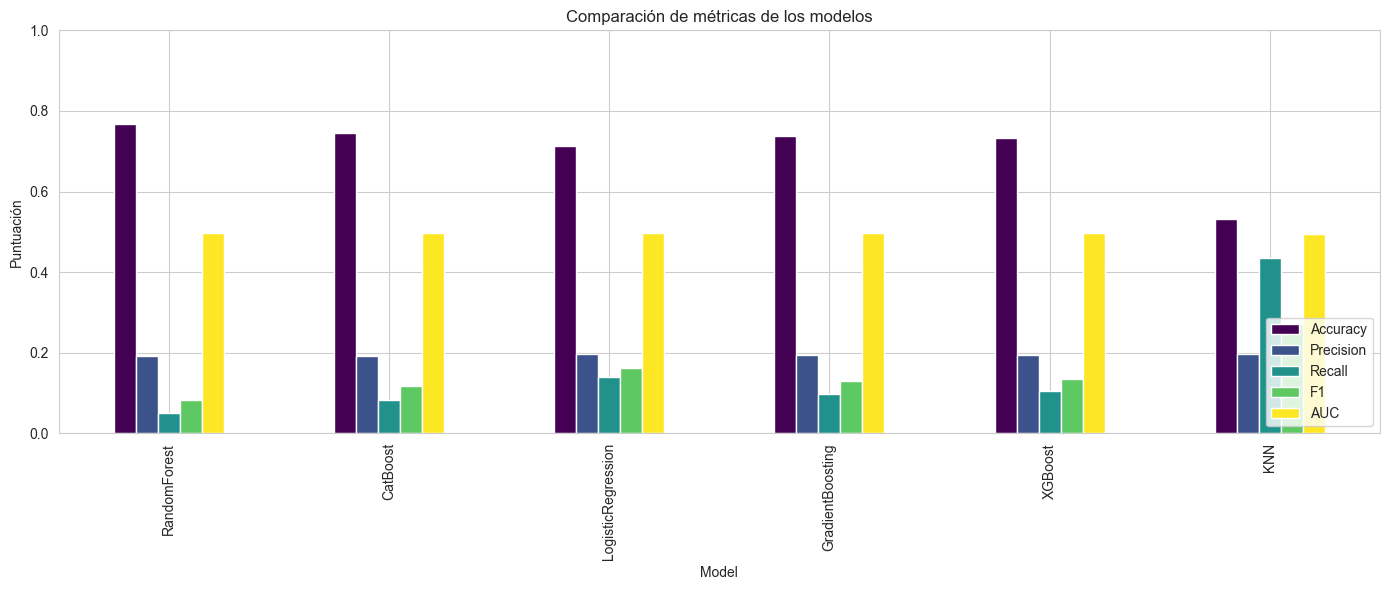

Gráfico guardado en: resultadosML\barras_comparativas_modelos.png


In [35]:
# Métricas a graficar
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

# Gráfico de barras
results_df[metrics_to_plot].plot(kind='bar', figsize=(14, 6), colormap='viridis')

plt.title('Comparación de métricas de los modelos')
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()

file_path_plot = os.path.join(output_dir, "barras_comparativas_modelos.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

### Matrices de confusión para cada modelo

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16,10))
axes = axes.flatten()
for idx, (name, model) in enumerate(best_models.items()):
  y_pred = model.predict(X_test_scaled)
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
  axes[idx].set_title(f'{name}\nMatriz de confusión')
  axes[idx].set_xlabel('Predicho')
  axes[idx].set_ylabel('Real')

# Ocultar último subplot
if len(best_models) < 8:
  axes[-1].axis('off')
plt.tight_layout()
plt.savefig('matrices_confusion.png')
plt.show()

### Curva ROC para cada modelo

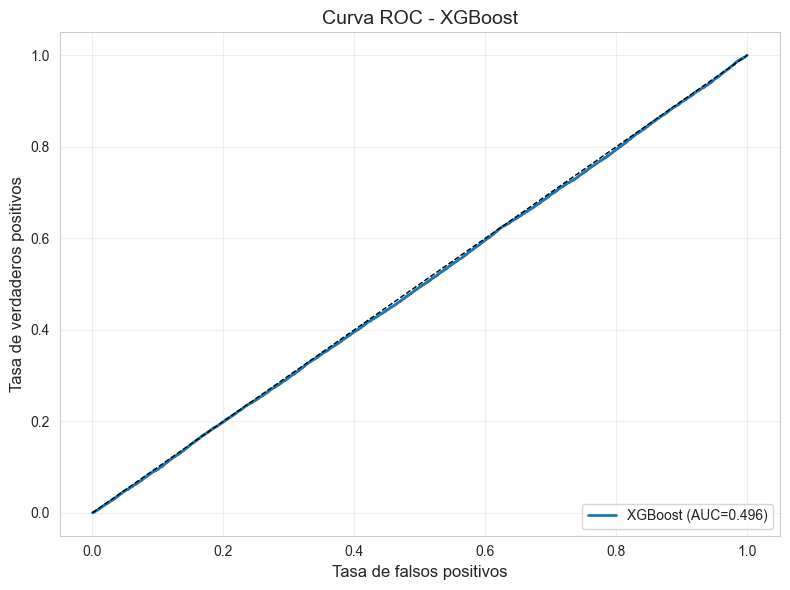

ROC guardada en: resultadosML\roc_XGBoost.png


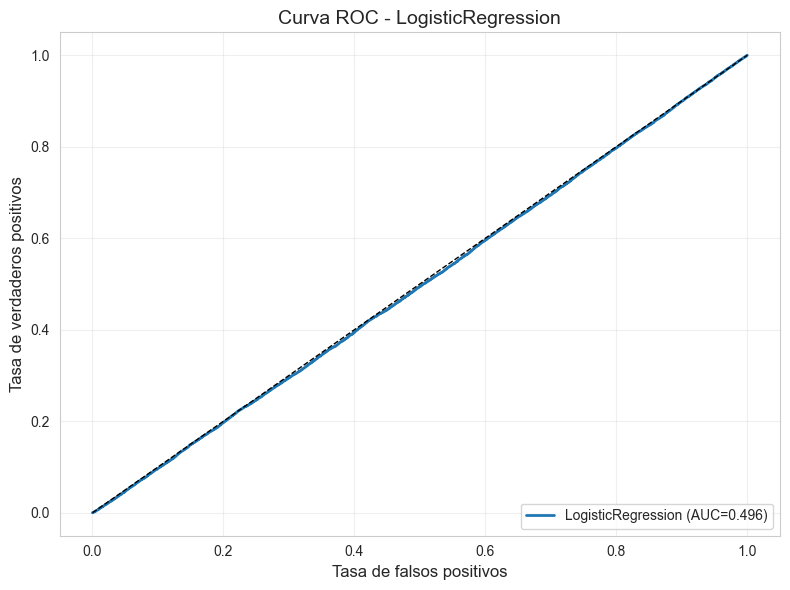

ROC guardada en: resultadosML\roc_LogisticRegression.png


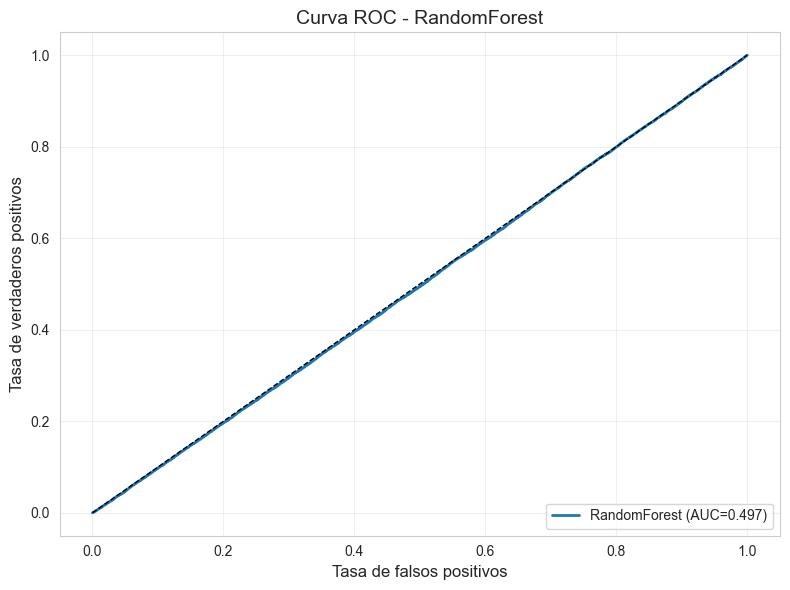

ROC guardada en: resultadosML\roc_RandomForest.png


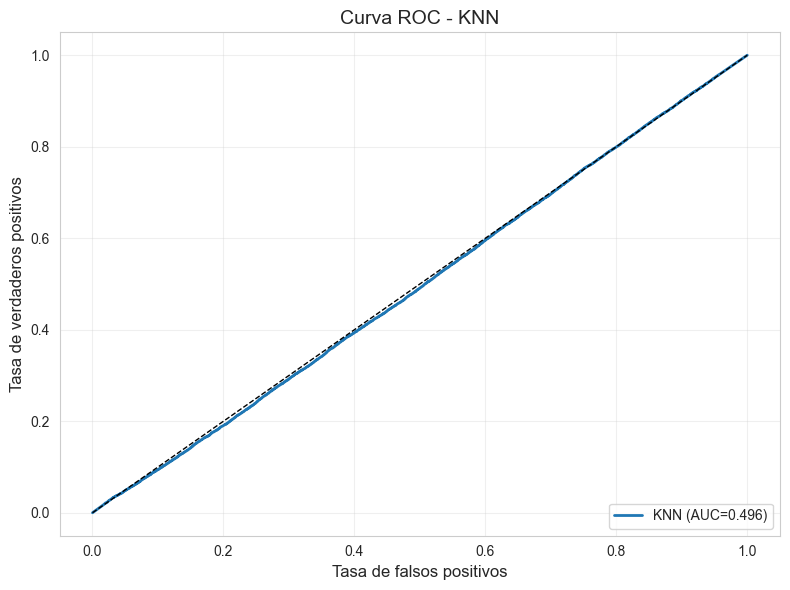

ROC guardada en: resultadosML\roc_KNN.png


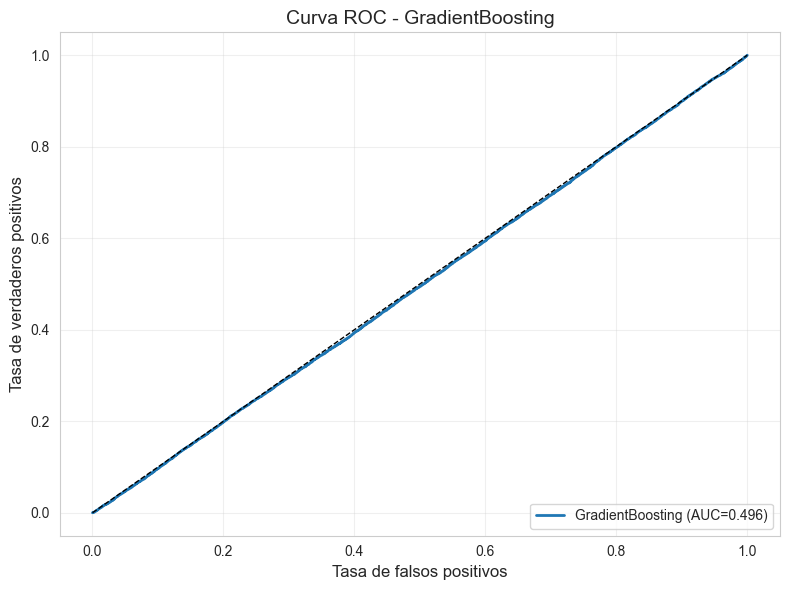

ROC guardada en: resultadosML\roc_GradientBoosting.png


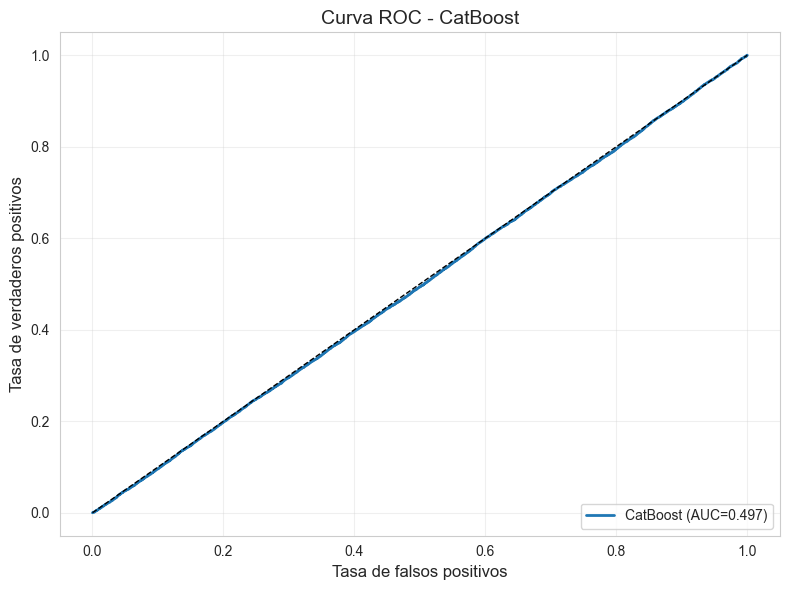

ROC guardada en: resultadosML\roc_CatBoost.png

Curvas ROC guardadas en la carpeta 'resultadosML/'


In [36]:
for name, model in best_models.items():
    plt.figure(figsize=(8, 6))

    try:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    except:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

    plt.xlabel('Tasa de falsos positivos', fontsize=12)
    plt.ylabel('Tasa de verdaderos positivos', fontsize=12)
    plt.title(f'Curva ROC - {name}', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Guardar directamente en resultadosML
    file_path_roc = os.path.join(output_dir, f"roc_{name}.png")
    plt.savefig(file_path_roc, dpi=150)

    plt.show()
    plt.close()

    print(f"ROC guardada en: {file_path_roc}")

print("\nCurvas ROC guardadas en la carpeta 'resultadosML/'")

## Seleción del mejor modelo

In [ ]:
results_df['Score'] = results_df['Recall'] + results_df['AUC']
best_model_name = results_df['Score'].idxmax()
best_model = best_models[best_model_name]
print(f"\nMejor modelo seleccionado: {best_model_name}")
print(f"Recall: {results_df.loc[best_model_name, 'Recall']:.4f}, AUC: {results_df.loc[best_model_name, 'AUC']:.4f}")

### XAI con SHAP

In [ ]:
print("\nGenerando explicaciones SHAP para el mejor modelo...")
X_test_shap = X_test_scaled.copy()

# Selección de XAI según modelo
if best_model_name in ['RandomForest', 'XGBoost', 'GradientBoosting', 'CatBoost']:
  # Modelos básados en árboles: TreeExplainer
  explainer = shap.TreeExplainer(best_model)
  shap_values = explainer.shap_values(X_test_shap)
  if isinstance(shap_values, list):
    shap_values = shap_values[1]

else:
  # Modelos lineales: KernelExplainer
  background = shap.sample(X_train_resampled, 100) # 100 instanciasde entrenamiento
  explainer = shap.KernelExplainer(best_model.predict_proba, background)
  shap_values = explainer.shap_values(X_test_shap, nsamples=100)
  if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Summary plot (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_shap, feature_names=X.columns, show=False)
plt.title(f'SHAP Summary Plot - {best_model_name}')
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()

# Bar plot de importancia global
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap, feature_names=X.columns, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance - {best_model_name}')
plt.tight_layout()
plt.savefig('shap_importance.png')
plt.show()